In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import ViTModel
from torch.utils.data import Dataset,DataLoader,TensorDataset
import json
import cv2
import numpy as np
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utils

In [ ]:

def get_target(q,T,x_min,y_min,w,h,K):
    bx=x_min+w/2
    by=y_min+h/2

    q_scipy=[q[1],q[2],q[3],q[0]]
    R_mat=R.from_quat(q_scipy).as_matrix()


    fx,fy=K[0,0],K[1,1]
    cx,cy=K[0,2],K[1,2]

    X,Y,Z=T

    x=fx*X/Z+cx
    y=fy*Y/Z+cy

    Ux=(x-bx)/w
    Uy=(y-by)/h

    W,H=1920,1200

    alpha=1.6

    sx=W/(alpha*w)
    sy=H/(h)

    Uz=0.5*(1/sx+1/sy)*Z


    T_vec=np.array([X,Y,Z])
    T_hat=T_vec/(np.linalg.norm(T_vec)+1e-8)

    ez=np.array([0,0,1])

    u=np.cross(T_hat,ez)

    norm_u=np.linalg.norm(u)

    if norm_u<1e-6:
        delta_R=np.eye(3)

    else:
        u=u/norm_u
        theta=np.arccos(np.clip(np.dot(T_hat,ez),-1,1))

        skew_symm_m=np.array([
            [0, -u[2], u[1]],
            [u[2], 0, -u[0]],
            [-u[1], u[0], 0]
        ])

        delta_R=np.eye(3)+np.sin(theta)*skew_symm_m+(1-np.cos(theta))*(skew_symm_m@skew_symm_m)

    R_prime=delta_R@R_mat

    r1_hat=R_prime[:,0]
    r2_hat=R_prime[:,1]

    target=np.concatenate([[Ux,Uy,Uz],r1_hat,r2_hat])
    R_prime=R_prime.flatten()

    return target,T_vec,R_mat


def get_inference(pred,bbox,K):
    K=torch.tensor(K,dtype=torch.float32,device=pred.device)
    bbox=bbox.to(pred.device)
    x_min=bbox[:,0]
    y_min=bbox[:,1]
    w=bbox[:,2]
    h=bbox[:,3]

    bx=x_min+w/2
    by=y_min+h/2

    fx,fy=K[0,0],K[1,1]
    cx,cy=K[0,2],K[1,2]

    W,H=1920,1200

    alpha=1.6

    Ux=pred[:,0]
    Uy=pred[:,1]
    Uz=pred[:,2]

    r1_hat=pred[:,3:6]
    r2_hat=pred[:,6:9]

    sx=W/(alpha*w)
    sy=H/h

    Z=Uz/(0.5*(1/sx+1/sy))

    X=(bx+Ux*w-cx)*Z/fx
    Y=(by+Uy*h-cy)*Z/fy

    r1=nn.functional.normalize(r1_hat,dim=1)
    r2=r2_hat-torch.sum(r2_hat*r1,dim=1,keepdim=True)*r1
    r2=nn.functional.normalize(r2,dim=1)
    r3=torch.cross(r1,r2,dim=1)
    R_prime=torch.stack([r1,r2,r3],axis=2)


    T_vec=torch.stack([X,Y,Z],axis=1)
    T_hat=nn.functional.normalize(T_vec,dim=1)

    ez=torch.tensor([0,0,1],dtype=torch.float32,device=pred.device).expand(pred.shape[0],3)

    u=torch.cross(T_hat,ez,dim=1)

    u=nn.functional.normalize(u,dim=1)


    theta=torch.acos(torch.clamp(torch.sum(T_hat*ez,dim=1),-1,1))

    ux,uy,uz=u[:,0],u[:,1],u[:,2]

    zero=torch.zeros_like(ux)
    skew_symm_m=torch.stack([
        torch.stack([zero,-uz,uy],dim=1),
        torch.stack([uz,zero,-ux],dim=1),
        torch.stack([-uy,ux,zero],dim=1)
    ],dim=1)

    sin_theta=torch.sin(theta).unsqueeze(-1).unsqueeze(-1)
    cos_theta=torch.cos(theta).unsqueeze(-1).unsqueeze(-1)

    delta_R=torch.eye(3,device=pred.device).unsqueeze(0).expand(pred.shape[0],3,3)+sin_theta*skew_symm_m+(1-cos_theta)*torch.bmm(skew_symm_m,skew_symm_m)
    R_pred=torch.bmm(delta_R.transpose(1,2),R_prime)
    return T_vec,R_pred





    # delta_R=np.eye(3)+np.sin(theta)*skew_symm_m+(1-np.cos(theta))*(skew_symm_m@skew_symm_m)

    # R_pred=delta_R.T@R_prime

    # return T_vec,R_pred






# Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("isidorotamassia/speed")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'speed' dataset.
Path to dataset files: /kaggle/input/speed


In [ ]:
K=np.array([
    [2988.5795163815555, 0, 960],
    [0, 2988.3401159176124, 600],
    [0, 0, 1]
])



class PoseDatatset(Dataset):
  def __init__(self,json_path,img_dir):
    with open(json_path,'r') as f:
      self.data=json.load(f)
    self.img_dir=img_dir
  def __len__(self):
    return len(self.data)

  def __getitem__(self,idx):
    item=self.data[idx]
    img_path=self.img_dir+"/"+item['filename']
    img=cv2.imread(img_path)

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    x_min=int(item['x_min'])
    y_min=int(item['y_min'])
    w=int(item['w'])
    h=int(item['h'])

    crop_img=img[y_min:y_min+h,x_min:x_min+w]

    crop_img=cv2.resize(crop_img,(224,224))
    crop_img=crop_img.astype(np.float32)
    crop_img=crop_img/255.0
    crop_img=torch.from_numpy(crop_img)
    crop_img=crop_img.permute(2,0,1)



    target,T,R_prime=get_target(item['q'],item['T'],x_min,y_min,w,h,K)
    crop_img=crop_img.to(torch.float32)
    target=torch.tensor(target,dtype=torch.float32)
    bbox=torch.tensor([x_min,y_min,w,h],dtype=torch.float32)
    T=torch.tensor(T,dtype=torch.float32)
    R_prime=torch.tensor(R_prime,dtype=torch.float32)


    return crop_img,target,T,R_prime,bbox



In [ ]:
train_ds=PoseDatatset("pose_train.json",path+"/speedplusv2/synthetic/images")
train_loader=DataLoader(train_ds,batch_size=16,shuffle=True)

In [ ]:
val_ds=PoseDatatset("pose_val.json",path+"/speedplusv2/synthetic/images")
val_loader=DataLoader(val_ds,batch_size=16,shuffle=True)

In [ ]:
class FPV(nn.Module):
  def __init__(self):
    super().__init__()
    self.vit=ViTModel.from_pretrained('google/vit-base-patch16-224')
    embed_dim=self.vit.config.hidden_size
    self.fc=nn.Linear(embed_dim,9)

  def forward(self,x):
    x=self.vit(pixel_values=x)
    cls_token=x.last_hidden_state[:,0]
    return self.fc(cls_token)


In [ ]:
model=FPV().to(device)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
crit=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=1e-4)
num_epochs=50

In [ ]:
def translation_error(T_pred,T_gt):
  return torch.norm(T_pred-T_gt,dim=1).mean()

In [ ]:
def rotation_error(R_pred,R_gt):
  R_gt=R_gt.view(-1,3,3)
  R_mul=torch.bmm(R_pred.transpose(1,2),R_gt)
  trace=R_mul[:,0,0]+R_mul[:,1,1]+R_mul[:,2,2]
  cos_theta=(trace-1)/2
  cos_theta=torch.clamp(cos_theta,-1,1)
  theta=torch.acos(cos_theta)
  theta_deg=torch.rad2deg(theta)
  theta_error=torch.mean(theta_deg)

  return theta_error

In [ ]:
def check_val():
  model.eval()
  print("Evaluaion Begins")
  t_error=0
  r_error=0
  for x,y,T,R_prime,bbox in tqdm(val_loader):
    x=x.to(device)
    y=y.to(device)
    T=T.to(device)
    R_prime=R_prime.to(device)
    bbox=bbox.to(device)
    T_pred,R_prime_pred=get_inference(model(x),bbox,K)
    t_error+=translation_error(T_pred,T).item()
    r_error+=rotation_error(R_prime_pred,R_prime).item()
  print(f"Translation Error: {t_error/len(val_loader)}")
  print(f"Rotation Error: {r_error/len(val_loader)}")
  model.train()


In [ ]:
for epochs in range(num_epochs):
  mean_loss=0
  for x,y,_,_,_ in tqdm(train_loader):
    x=x.to(device)
    y=y.to(device)
    pred=model(x)
    loss=crit(pred,y)
    mean_loss+=loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(f"Epoch: {epochs+1} Loss: {mean_loss/len(train_loader)}")

  if (epochs+1)%5==0:
    check_val()
    torch.save(model.state_dict(),f"model_{epochs+1}.pt")



100%|██████████| 2998/2998 [31:20<00:00,  1.59it/s]


Epoch: 1 Loss: 0.0037820044565525556


  0%|          | 6/2998 [00:03<32:36,  1.53it/s]


KeyboardInterrupt: 

In [ ]:
check_val()
torch.save(model.state_dict(),f"model_{epochs+1}.pt")

Evaluaion Begins


100%|██████████| 750/750 [05:45<00:00,  2.17it/s]


Translation Error: 0.1035479662468036
Rotation Error: 6.302459763526916


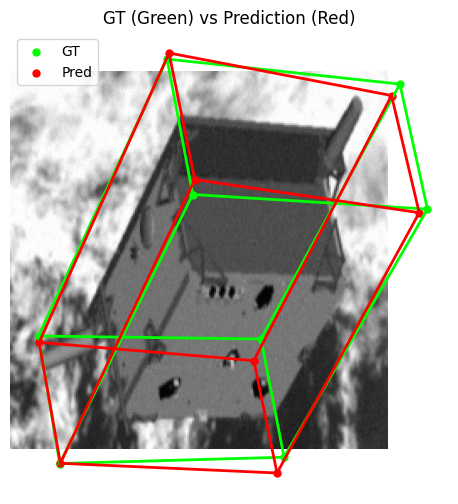

In [ ]:
import cv2
import matplotlib.pyplot as plt
from scipy.io import loadmat


for img,target,T_gt,R_gt,bbox in val_loader:
    img=img.to(device)
    bbox=bbox.to(device)
    T_gt=T_gt.to(device)
    R_gt=R_gt.to(device)
    break

img_vis=img[0].permute(1,2,0).cpu().numpy()

K = np.array([
    [2988.5795163815555, 0, 960],
    [0, 2988.3401159176124, 600],
    [0, 0, 1]
])


data = loadmat("tangoPoints.mat")
points_3D = data['tango3Dpoints']


xmin,ymin,zmin=points_3D.min(axis=1)
xmax,ymax,zmax=points_3D.max(axis=1)

bbox_3D=np.array([
    [xmin,ymin,zmin],
    [xmax,ymin,zmin],
    [xmax,ymax,zmin],
    [xmin,ymax,zmin],
    [xmin,ymin,zmax],
    [xmax,ymin,zmax],
    [xmax,ymax,zmax],
    [xmin,ymax,zmax],
])


with torch.no_grad():
    T_pred, R_pred = get_inference(model(img), bbox, K)

R_pred = R_pred[0].cpu().numpy()
T_pred = T_pred[0].cpu().numpy()


R_gt = R_gt[0].cpu().numpy().reshape(3,3)
T_gt = T_gt[0].cpu().numpy()

def project_bbox(R_mat, t_vec):
    points_cam = (R_mat @ bbox_3D.T).T + t_vec

    valid = points_cam[:, 2] > 0
    points_cam = points_cam[valid]

    points_2D = (K @ points_cam.T).T
    points_2D = points_2D[:, :2] / points_2D[:, 2:]


    x_min, y_min, w, h = bbox[0].cpu().numpy()

    points_2D[:, 0] -= x_min
    points_2D[:, 1] -= y_min

    points_2D[:, 0] *= 224 / w
    points_2D[:, 1] *= 224 / h

    return points_2D


pts_pred = project_bbox(R_pred, T_pred)
pts_gt   = project_bbox(R_gt, T_gt)


fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_vis)

edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]


for i, j in edges:
    if i < len(pts_gt) and j < len(pts_gt):
        ax.plot([pts_gt[i,0], pts_gt[j,0]],
                [pts_gt[i,1], pts_gt[j,1]],
                color='lime', linewidth=2)

ax.scatter(pts_gt[:,0], pts_gt[:,1], color='lime', s=25, label='GT')


for i, j in edges:
    if i < len(pts_pred) and j < len(pts_pred):
        ax.plot([pts_pred[i,0], pts_pred[j,0]],
                [pts_pred[i,1], pts_pred[j,1]],
                color='red', linewidth=2)

ax.scatter(pts_pred[:,0], pts_pred[:,1], color='red', s=25, label='Pred')

ax.set_title("GT (Green) vs Prediction (Red)")
ax.legend()
ax.axis('off')

plt.show()

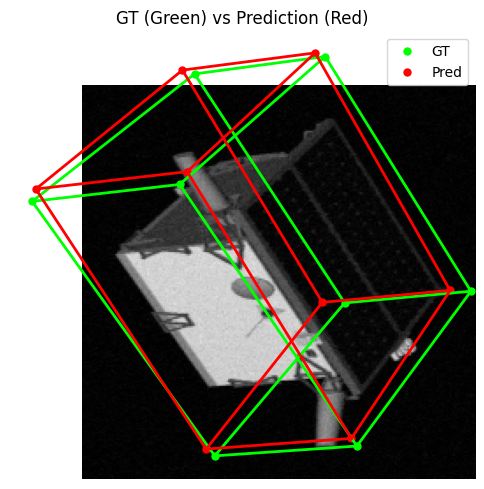

In [ ]:
import cv2
import matplotlib.pyplot as plt
from scipy.io import loadmat


for img,target,T_gt,R_gt,bbox in val_loader:
    img=img.to(device)
    bbox=bbox.to(device)
    T_gt=T_gt.to(device)
    R_gt=R_gt.to(device)
    break

img_vis=img[0].permute(1,2,0).cpu().numpy()

K = np.array([
    [2988.5795163815555, 0, 960],
    [0, 2988.3401159176124, 600],
    [0, 0, 1]
])


data = loadmat("tangoPoints.mat")
points_3D = data['tango3Dpoints']


xmin,ymin,zmin=points_3D.min(axis=1)
xmax,ymax,zmax=points_3D.max(axis=1)

bbox_3D=np.array([
    [xmin,ymin,zmin],
    [xmax,ymin,zmin],
    [xmax,ymax,zmin],
    [xmin,ymax,zmin],
    [xmin,ymin,zmax],
    [xmax,ymin,zmax],
    [xmax,ymax,zmax],
    [xmin,ymax,zmax],
])


with torch.no_grad():
    T_pred, R_pred = get_inference(model(img), bbox, K)

R_pred = R_pred[0].cpu().numpy()
T_pred = T_pred[0].cpu().numpy()


R_gt = R_gt[0].cpu().numpy().reshape(3,3)
T_gt = T_gt[0].cpu().numpy()

def project_bbox(R_mat, t_vec):
    points_cam = (R_mat @ bbox_3D.T).T + t_vec

    valid = points_cam[:, 2] > 0
    points_cam = points_cam[valid]

    points_2D = (K @ points_cam.T).T
    points_2D = points_2D[:, :2] / points_2D[:, 2:]


    x_min, y_min, w, h = bbox[0].cpu().numpy()

    points_2D[:, 0] -= x_min
    points_2D[:, 1] -= y_min

    points_2D[:, 0] *= 224 / w
    points_2D[:, 1] *= 224 / h

    return points_2D


pts_pred = project_bbox(R_pred, T_pred)
pts_gt   = project_bbox(R_gt, T_gt)


fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_vis)

edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]


for i, j in edges:
    if i < len(pts_gt) and j < len(pts_gt):
        ax.plot([pts_gt[i,0], pts_gt[j,0]],
                [pts_gt[i,1], pts_gt[j,1]],
                color='lime', linewidth=2)

ax.scatter(pts_gt[:,0], pts_gt[:,1], color='lime', s=25, label='GT')


for i, j in edges:
    if i < len(pts_pred) and j < len(pts_pred):
        ax.plot([pts_pred[i,0], pts_pred[j,0]],
                [pts_pred[i,1], pts_pred[j,1]],
                color='red', linewidth=2)

ax.scatter(pts_pred[:,0], pts_pred[:,1], color='red', s=25, label='Pred')

ax.set_title("GT (Green) vs Prediction (Red)")
ax.legend()
ax.axis('off')

plt.show()

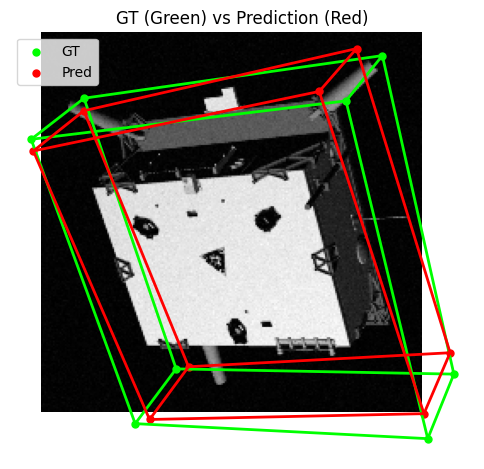

In [ ]:
import cv2
import matplotlib.pyplot as plt
from scipy.io import loadmat


for img,target,T_gt,R_gt,bbox in val_loader:
    img=img.to(device)
    bbox=bbox.to(device)
    T_gt=T_gt.to(device)
    R_gt=R_gt.to(device)
    break

img_vis=img[0].permute(1,2,0).cpu().numpy()

K = np.array([
    [2988.5795163815555, 0, 960],
    [0, 2988.3401159176124, 600],
    [0, 0, 1]
])


data = loadmat("tangoPoints.mat")
points_3D = data['tango3Dpoints']


xmin,ymin,zmin=points_3D.min(axis=1)
xmax,ymax,zmax=points_3D.max(axis=1)

bbox_3D=np.array([
    [xmin,ymin,zmin],
    [xmax,ymin,zmin],
    [xmax,ymax,zmin],
    [xmin,ymax,zmin],
    [xmin,ymin,zmax],
    [xmax,ymin,zmax],
    [xmax,ymax,zmax],
    [xmin,ymax,zmax],
])


with torch.no_grad():
    T_pred, R_pred = get_inference(model(img), bbox, K)

R_pred = R_pred[0].cpu().numpy()
T_pred = T_pred[0].cpu().numpy()


R_gt = R_gt[0].cpu().numpy().reshape(3,3)
T_gt = T_gt[0].cpu().numpy()

def project_bbox(R_mat, t_vec):
    points_cam = (R_mat @ bbox_3D.T).T + t_vec

    valid = points_cam[:, 2] > 0
    points_cam = points_cam[valid]

    points_2D = (K @ points_cam.T).T
    points_2D = points_2D[:, :2] / points_2D[:, 2:]


    x_min, y_min, w, h = bbox[0].cpu().numpy()

    points_2D[:, 0] -= x_min
    points_2D[:, 1] -= y_min

    points_2D[:, 0] *= 224 / w
    points_2D[:, 1] *= 224 / h

    return points_2D


pts_pred = project_bbox(R_pred, T_pred)
pts_gt   = project_bbox(R_gt, T_gt)


fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img_vis)

edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]


for i, j in edges:
    if i < len(pts_gt) and j < len(pts_gt):
        ax.plot([pts_gt[i,0], pts_gt[j,0]],
                [pts_gt[i,1], pts_gt[j,1]],
                color='lime', linewidth=2)

ax.scatter(pts_gt[:,0], pts_gt[:,1], color='lime', s=25, label='GT')


for i, j in edges:
    if i < len(pts_pred) and j < len(pts_pred):
        ax.plot([pts_pred[i,0], pts_pred[j,0]],
                [pts_pred[i,1], pts_pred[j,1]],
                color='red', linewidth=2)

ax.scatter(pts_pred[:,0], pts_pred[:,1], color='red', s=25, label='Pred')

ax.set_title("GT (Green) vs Prediction (Red)")
ax.legend()
ax.axis('off')

plt.show()